# IMDb Movies Analysis using Apache Beam
This notebook demonstrates how to use Apache Beam to process structured CSV data.  
We use the IMDb Movies dataset to perform aggregations like average scores, movie counts, budgets, and gross revenue — all using Beam's parallel processing pipeline.

## Dataset
- **Source**: [Kaggle - IMDb Movies Dataset](https://www.kaggle.com/datasets/danielgrijalvas/movies)
- **Records**: ~7,600 movies
- **Key columns**: name, genre, year, score, budget, gross, rating, runtime

In [1]:
import apache_beam as beam
import csv
import io
import matplotlib.pyplot as plt

print("Apache Beam version:", beam.__version__)

Apache Beam version: 2.71.0


## Step 1: Preview the Dataset

In [2]:
import pandas as pd
df = pd.read_csv('data/movies.csv')
print(f"Total records: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head()

Total records: 7668
Columns: ['name', 'rating', 'genre', 'year', 'released', 'score', 'votes', 'director', 'writer', 'star', 'country', 'budget', 'gross', 'company', 'runtime']


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


## Step 2: Define Helper Functions
These functions handle CSV parsing, data validation, and safe type conversion.

In [3]:
def parse_csv(line):
    """Parse a single CSV line into a dictionary."""
    reader = csv.reader(io.StringIO(line))
    fields = next(reader)
    headers = [
        'name', 'rating', 'genre', 'year', 'released',
        'score', 'votes', 'director', 'writer', 'star',
        'country', 'budget', 'gross', 'company', 'runtime'
    ]
    if len(fields) != len(headers):
        return None
    return dict(zip(headers, fields))

def is_valid_record(record):
    """Filter out None records and header row."""
    if record is None:
        return False
    if record.get('name') == 'name':
        return False
    return True

def safe_float(value):
    """Safely convert a value to float, return None if invalid."""
    try:
        return float(value)
    except (ValueError, TypeError):
        return None

class AverageFn(beam.CombineFn):
    """Custom CombineFn to compute average."""
    def create_accumulator(self):
        return (0.0, 0)

    def add_input(self, accumulator, input_value):
        total, count = accumulator
        return (total + input_value, count + 1)

    def merge_accumulators(self, accumulators):
        totals, counts = zip(*accumulators)
        return (sum(totals), sum(counts))

    def extract_output(self, accumulator):
        total, count = accumulator
        return round(total / count, 2) if count > 0 else 0.0

def format_result(kv, label):
    """Format a key-value pair into a readable string."""
    return f'{label} | {kv[0]}: {kv[1]}'

print("Helper functions defined successfully!")

Helper functions defined successfully!


## Step 3: Define Transform Functions
Each function extracts specific key-value pairs for different aggregations.

In [4]:
def extract_genre_score(record):
    score = safe_float(record.get('score'))
    genre = record.get('genre', '').strip()
    if score is not None and genre:
        return [(genre, score)]
    return []

def extract_genre_count(record):
    genre = record.get('genre', '').strip()
    if genre:
        return [(genre, 1)]
    return []

def extract_year_budget(record):
    budget = safe_float(record.get('budget'))
    year = record.get('year', '').strip()
    if budget is not None and year and budget > 0:
        return [(year, budget)]
    return []

def extract_genre_gross(record):
    gross = safe_float(record.get('gross'))
    genre = record.get('genre', '').strip()
    if gross is not None and genre and gross > 0:
        return [(genre, gross)]
    return []

print("Transform functions defined successfully!")

Transform functions defined successfully!


## Step 4: Run the Beam Pipeline
We run 4 aggregations in a single pipeline using the DirectRunner:
1. **Average IMDb Score per Genre**
2. **Movie Count per Genre**
3. **Average Budget per Year**
4. **Total Gross Revenue per Genre**

In [5]:
input_file = 'data/movies.csv'

with beam.Pipeline() as pipeline:
    records = (
        pipeline
        | 'ReadCSV' >> beam.io.ReadFromText(input_file)
        | 'ParseCSV' >> beam.Map(parse_csv)
        | 'FilterInvalid' >> beam.Filter(is_valid_record)
    )

    # 1. Average IMDb Score per Genre
    (
        records
        | 'ExtractGenreScore' >> beam.FlatMap(extract_genre_score)
        | 'AvgScorePerGenre' >> beam.CombinePerKey(AverageFn())
        | 'FormatAvgScore' >> beam.Map(format_result, 'AvgScore')
        | 'WriteAvgScore' >> beam.io.WriteToText(
            'outputs/avg_score_per_genre', file_name_suffix='.txt')
    )

    # 2. Movie Count per Genre
    (
        records
        | 'ExtractGenreCount' >> beam.FlatMap(extract_genre_count)
        | 'SumCountPerGenre' >> beam.CombinePerKey(sum)
        | 'FormatCount' >> beam.Map(format_result, 'MovieCount')
        | 'WriteCount' >> beam.io.WriteToText(
            'outputs/movie_count_per_genre', file_name_suffix='.txt')
    )

    # 3. Average Budget per Year
    (
        records
        | 'ExtractYearBudget' >> beam.FlatMap(extract_year_budget)
        | 'AvgBudgetPerYear' >> beam.CombinePerKey(AverageFn())
        | 'FormatBudget' >> beam.Map(format_result, 'AvgBudget')
        | 'WriteBudget' >> beam.io.WriteToText(
            'outputs/avg_budget_per_year', file_name_suffix='.txt')
    )

    # 4. Total Gross Revenue per Genre
    (
        records
        | 'ExtractGenreGross' >> beam.FlatMap(extract_genre_gross)
        | 'SumGrossPerGenre' >> beam.CombinePerKey(sum)
        | 'FormatGross' >> beam.Map(format_result, 'TotalGross')
        | 'WriteGross' >> beam.io.WriteToText(
            'outputs/total_gross_per_genre', file_name_suffix='.txt')
    )

print("Pipeline completed! Check the 'outputs/' folder.")

I0000 00:00:1774662265.855731 2960684 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers


Pipeline completed! Check the 'outputs/' folder.


I0000 00:00:1774662266.948803 2960832 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers


## Step 5: View Results

In [6]:
import os

output_files = [
    ('Average Score per Genre', 'outputs/avg_score_per_genre-00000-of-00001.txt'),
    ('Movie Count per Genre', 'outputs/movie_count_per_genre-00000-of-00001.txt'),
    ('Average Budget per Year', 'outputs/avg_budget_per_year-00000-of-00001.txt'),
    ('Total Gross per Genre', 'outputs/total_gross_per_genre-00000-of-00001.txt'),
]

for title, filepath in output_files:
    print(f"\n{'='*50}")
    print(f"  {title}")
    print(f"{'='*50}")
    if os.path.exists(filepath):
        with open(filepath, 'r') as f:
            for line in f:
                print(line.strip())


  Average Score per Genre
AvgScore | Thriller: 5.91
AvgScore | Fantasy: 6.01
AvgScore | Music: 7.2
AvgScore | History: 8.3
AvgScore | Adventure: 6.29
AvgScore | Drama: 6.69
AvgScore | Biography: 7.03
AvgScore | Crime: 6.67
AvgScore | Mystery: 6.67
AvgScore | Comedy: 6.19
AvgScore | Sci-Fi: 6.21
AvgScore | Family: 6.36
AvgScore | Horror: 5.75
AvgScore | Animation: 6.77
AvgScore | Sport: 5.9
AvgScore | Musical: 8.05
AvgScore | Action: 6.2
AvgScore | Romance: 6.41
AvgScore | Western: 5.67

  Movie Count per Genre
MovieCount | Drama: 1518
MovieCount | Mystery: 20
MovieCount | Sport: 1
MovieCount | History: 1
MovieCount | Family: 11
MovieCount | Horror: 322
MovieCount | Fantasy: 44
MovieCount | Animation: 338
MovieCount | Western: 3
MovieCount | Music: 1
MovieCount | Thriller: 16
MovieCount | Action: 1705
MovieCount | Crime: 551
MovieCount | Comedy: 2245
MovieCount | Romance: 10
MovieCount | Musical: 2
MovieCount | Adventure: 427
MovieCount | Biography: 443
MovieCount | Sci-Fi: 10

  Avera

## Step 6: Visualize Results
Let's create charts from the pipeline output to better understand the data.

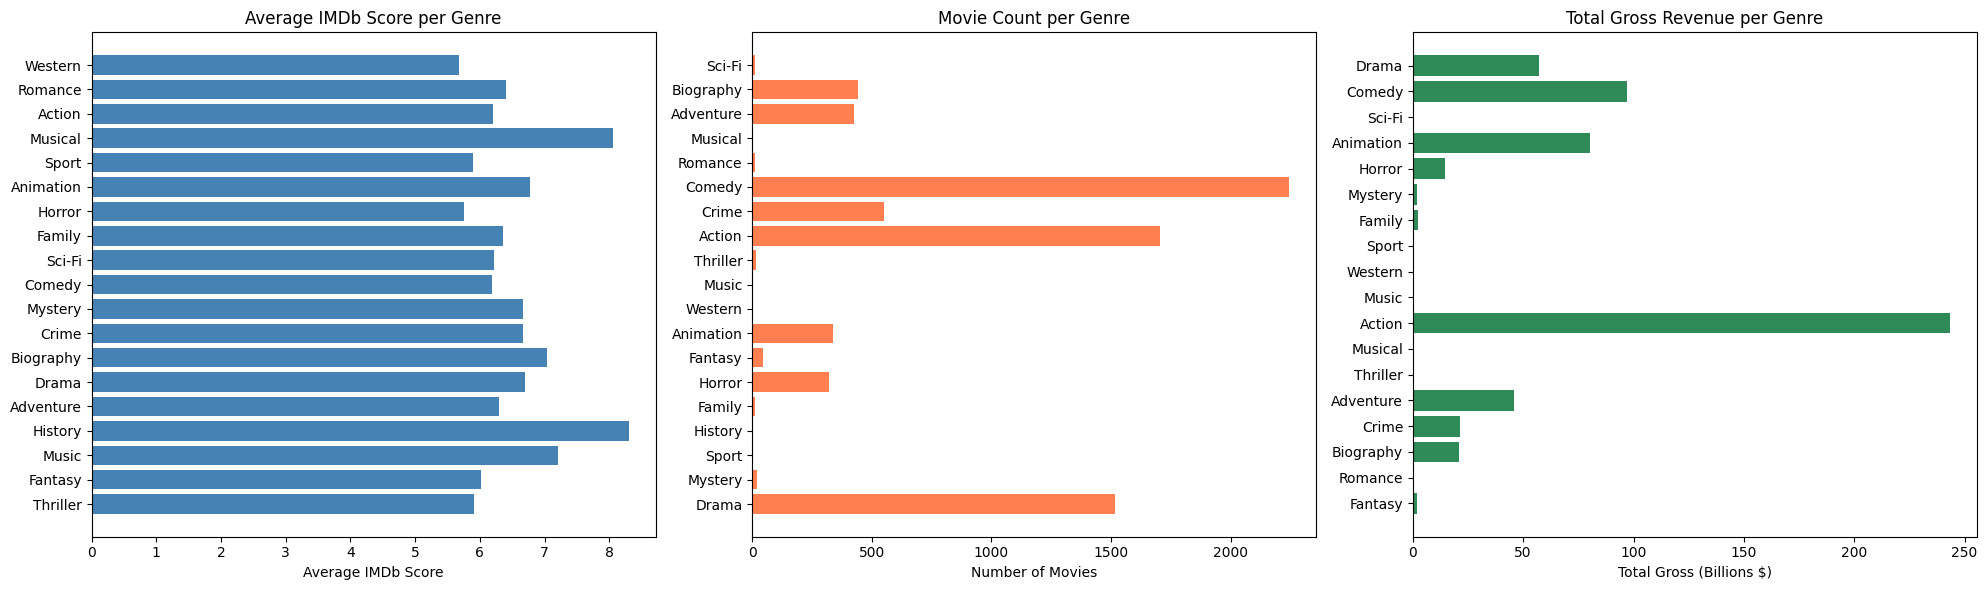

Charts saved to outputs/visualizations.png


In [7]:
def parse_output(filepath):
    """Parse output file into dictionary."""
    result = {}
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split(': ', 1)
            if len(parts) == 2:
                key = parts[0].split('| ')[1]
                value = float(parts[1])
                result[key] = value
    return result

# Parse all outputs
avg_scores = parse_output('outputs/avg_score_per_genre-00000-of-00001.txt')
movie_counts = parse_output('outputs/movie_count_per_genre-00000-of-00001.txt')
total_gross = parse_output('outputs/total_gross_per_genre-00000-of-00001.txt')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1: Avg Score per Genre
genres = list(avg_scores.keys())
scores = list(avg_scores.values())
axes[0].barh(genres, scores, color='steelblue')
axes[0].set_xlabel('Average IMDb Score')
axes[0].set_title('Average IMDb Score per Genre')

# Chart 2: Movie Count per Genre
genres2 = list(movie_counts.keys())
counts = list(movie_counts.values())
axes[1].barh(genres2, counts, color='coral')
axes[1].set_xlabel('Number of Movies')
axes[1].set_title('Movie Count per Genre')

# Chart 3: Total Gross per Genre (in billions)
genres3 = list(total_gross.keys())
gross_b = [v / 1e9 for v in total_gross.values()]
axes[2].barh(genres3, gross_b, color='seagreen')
axes[2].set_xlabel('Total Gross (Billions $)')
axes[2].set_title('Total Gross Revenue per Genre')

plt.tight_layout()
plt.savefig('outputs/visualizations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved to outputs/visualizations.png")